# Aashma Dangol
# 2408023

Task 1: Data Preparation (Using PIL)

In [1]:
import os
import numpy as np
from PIL import Image
from tensorflow.keras.utils import to_categorical

# 🔹 STEP 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 🔹 STEP 2: Set dataset paths from Drive
train_dir = "/content/drive/MyDrive/Train/"
test_dir = "/content/drive/MyDrive/Test/"

img_size = 28

def load_data(folder):
    images, labels = [], []
    class_names = sorted(os.listdir(folder))
    class_map = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for file in os.listdir(class_path):
            img_path = os.path.join(class_path, file)

            try:
                img = Image.open(img_path).convert("L")
                img = img.resize((img_size, img_size))
                img = np.array(img) / 255.0

                images.append(img)
                labels.append(label)
            except:
                print("Error loading:", img_path)

    return np.array(images), np.array(labels)

# 🔹 STEP 3: Load data
x_train, y_train = load_data(train_dir)
x_test, y_test = load_data(test_dir)

# 🔹 STEP 4: Flatten images
x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

# 🔹 STEP 5: One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 🔹 STEP 6: Check shapes
print("x_train:", x_train.shape, "y_train:", y_train.shape)
print("x_test:", x_test.shape, "y_test:", y_test.shape)

Mounted at /content/drive
x_train: (15006, 784) y_train: (15006, 10)
x_test: (3000, 784) y_test: (3000, 10)


Task 2: Build the FCN Mode

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(64, activation='sigmoid', input_shape=(784,)),   # 1st hidden
    Dense(128, activation='sigmoid'),                     # 2nd hidden
    Dense(256, activation='sigmoid'),                     # 3rd hidden
    Dense(10, activation='softmax')                       # Output
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

Task 3: Compile the Model

In [3]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Task 4: Train the Model

In [4]:
history = model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2
)

Epoch 1/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4439 - loss: 1.6942 - val_accuracy: 0.0000e+00 - val_loss: 4.9905
Epoch 2/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7829 - loss: 0.6127 - val_accuracy: 0.0260 - val_loss: 5.0946
Epoch 3/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8556 - loss: 0.3660 - val_accuracy: 0.1935 - val_loss: 4.9588
Epoch 4/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9378 - loss: 0.2219 - val_accuracy: 0.2089 - val_loss: 5.1428
Epoch 5/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9578 - loss: 0.1512 - val_accuracy: 0.2442 - val_loss: 5.3496
Epoch 6/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9654 - loss: 0.1180 - val_accuracy: 0.2732 - val_loss: 5.3862
Epoch 7/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9728 - loss: 0.0961 - val_accuracy: 0.2665 - val_loss: 5.5771
Epoch 8/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9793 - loss: 0.0783 - val_accuracy: 0.2805 - val_l

Task 5: Evaluate the Model

In [5]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7613 - loss: 2.2114
Test Accuracy: 0.7613333463668823
Test Loss: 2.2113935947418213


Task 6: Save & Load Model

In [6]:
# Save
model.save("devnagari_model.h5")

# Load
from tensorflow.keras.models import load_model
loaded_model = load_model("devnagari_model.h5")

# Re-evaluate
loss, acc = loaded_model.evaluate(x_test, y_test)
print("Loaded Model Accuracy:", acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7613 - loss: 2.2114
Loaded Model Accuracy: 0.7613333463668823


Task 7: Make Predictions

In [7]:
predictions = model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

print("Predicted labels:", predicted_labels[:10])
print("Actual labels:   ", true_labels[:10])

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Predicted labels: [0 0 0 0 0 0 7 0 0 0]
Actual labels:    [0 0 0 0 0 0 0 0 0 0]


Optional: Visualize Training

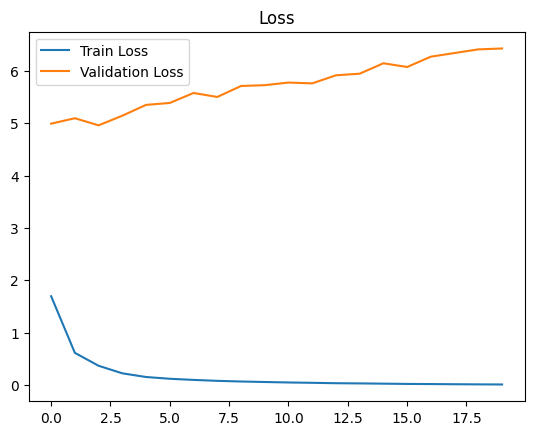

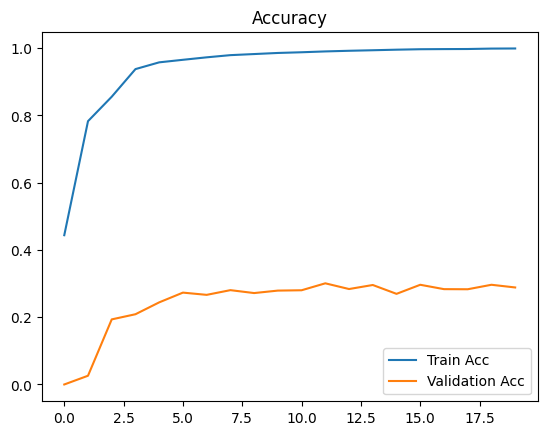

In [8]:
import matplotlib.pyplot as plt

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss")
plt.legend()
plt.show()

# Accuracy
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Validation Acc')
plt.title("Accuracy")
plt.legend()
plt.show()